# Neural Control Density Functions - PVTOL

This notebook adapts the NCDF framework to the 6 dimensional PVTOL system.

The state is $x=\begin{bmatrix} p_x,p_z,v_x,v_z,\phi,\dot{\phi}\end{bmatrix}$

In [31]:
# -*- coding: utf-8 -*-
# from dreal import *
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import cm
import random
import math

torch.manual_seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


# PVTOL
The dynamics is given by:
\begin{align}
    \begin{bmatrix}
        p_x\\
        p_z\\
        v_x\\
        v_z\\
        \phi\\
        \dot{\phi}
    \end{bmatrix}=\underbrace{\begin{bmatrix}
        v_x \cos \phi - v_z \sin \phi \\
        v_x \sin \phi + v_z \cos \phi \\
        \dot{\phi} \\
        v_z \dot{\phi} - g \sin \phi \\
        -v_x \dot{\phi}-g \cos \phi \\
        0
    \end{bmatrix}}_{f(x)} + \underbrace{ \begin{bmatrix}
        0 & 0 \\
        0 & 0 \\
        0 & 0 \\
        0 & 0 \\
        \frac{1}{m} &\frac{1}{m}\\
        \frac{l}{J} & \frac{-l}{J}
    \end{bmatrix}}_{g(x)}u
\end{align}
where $g=9.8,m=4,l=0.25,J=0.0475$

In [32]:
m = 4
l = 0.25
J= 0.0475
g = 9.81

def f(x):
    """
    x is [px, py, vx, vy, phi, dotphi]
    """
    f0 = x[2]*torch.cos(x[4]) - x[3]*torch.sin(x[4])
    f1 = x[2]*torch.sin(x[4]) + x[3]*torch.cos(x[4])
    f3 = x[5]
    f4 = x[3]*x[5]-g*torch.sin(x[4])
    f5 = -x[2]*x[5]+g*torch.cos(x[4])
    f6 = torch.zeros_like(x[0])
    return torch.stack([f0, f1, f3, f4, f5, f6])

def g_matrix(x):
    zero  = torch.zeros(1, device=x.device).squeeze()
    col0 = torch.stack([
        zero,
        zero,
        zero,
        zero,
        torch.tensor(1.0, device=x.device)/m,
        torch.tensor(l, device=x.device)/J])
    col1 = torch.stack([
        zero,
        zero,
        zero,
        zero,
        torch.tensor(1.0, device=x.device)/m,
        -torch.tensor(l, device=x.device)/J])
    return torch.stack([col0, col1], dim=1)

print("f and g_matrix defined. Quick sanity check at x=0:")
x0 = torch.zeros(6, device=device)
print("  f(0):", f(x0))
print("  g(0):", g_matrix(x0))

f and g_matrix defined. Quick sanity check at x=0:
  f(0): tensor([0.0000, 0.0000, 0.0000, 0.0000, 9.8100, 0.0000])
  g(0): tensor([[ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000],
        [ 0.2500,  0.2500],
        [ 5.2632, -5.2632]])


## 3. General divergence via autograd

We compute the **divergence of any vector field** $v(x) \in \mathbb{R}^n$ as:
$$\nabla \cdot v = \sum_{i=1}^n \frac{\partial v_i}{\partial x_i}$$
using `torch.autograd.grad` for each output component.

We also keep a batched version for the training loop.

In [33]:
def divergence_of_vector_field(v_func, x):
    """
    Compute the divergence of a vector field v_func at a single point x.

    Args:
        v_func: callable x (shape n,) -> v (shape n,), must be differentiable.
        x: 1D tensor of shape (n,), does NOT need requires_grad beforehand.

    Returns:
        Scalar tensor: sum_i d v_i / d x_i, with graph attached.
    """
    x_ = x.clone().detach().requires_grad_(True)
    v  = v_func(x_)          # shape (n,)
    div = torch.zeros(1, device=x.device)
    for i in range(v.shape[0]):
        grad_i = torch.autograd.grad(
            v[i], x_, create_graph=True, retain_graph=True
        )[0]                  # shape (n,)
        div = div + grad_i[i]
    return div.squeeze()


def gradient_of_scalar(func, x):
    """
    Gradient of a scalar-valued function func at a single point x.
    Returns tensor of shape (n,), with graph attached.
    """
    x_ = x.clone().detach().requires_grad_(True)
    out = func(x_.unsqueeze(0)).squeeze()   # scalar
    grad = torch.autograd.grad(out, x_, create_graph=True)[0]
    return grad


def gradient_of_b_norm_sq(b_fun, x):
    """
    Gradient of ||b(x)||^2 at a single point x.
    Returns tensor of shape (n,), with graph attached.
    """
    x_ = x.clone().detach().requires_grad_(True)
    b_val = b_fun(x_.unsqueeze(0)).squeeze(0)   # shape (d,)
    norm_sq = torch.sum(b_val ** 2)
    grad = torch.autograd.grad(norm_sq, x_, create_graph=True)[0]
    return grad


print("Divergence utilities defined.")

# Quick sanity: divergence of f at x=0 should be -d/m * 2 = -0.01786...
x0 = torch.zeros(6, device=device)
div_f0 = divergence_of_vector_field(f, x0)
print(f"  div f(0) = {div_f0.item():.6f} ")

Divergence utilities defined.
  div f(0) = 0.000000 


## 4. Control density risk

Using the exponential parameterisation $\rho = a(x)/e^{\|x\|^2 + \|b(x)\|^2}$, $\psi = c(x)/e^{\|x\|^2+\|b(x)\|^2}$,
the divergence condition reduces to:

$$
\underbrace{\nabla \cdot \bigl(a(x)f(x) + g(x)c(x)\bigr)}_{\text{computed via autograd}}
- \,\bigl(a(x)f(x) + g(x)c(x)\bigr)^\top
  \bigl(2x +  \nabla \|b(x)\|^2\bigr) > 0
$$

Note: $g(x)c(x)$ is a matrix-vector product $(6\times2) \cdot (2\times1) = (6\times1)$.
The resulting vector lives in $\mathbb{R}^6$, so the divergence is well-defined.

In [34]:
def control_density_risk(x_batch, f_fun, g_mat_fun, a_fun, b_fun, c_fun):
    """
    Compute the (un-thresholded) density divergence condition for a batch of states.

    Args:
        x_batch : tensor (N, 6)
        f_fun   : x (6,) -> (6,)     drift vector field
        g_mat_fun : x (6,) -> (6,2)  input matrix
        a_fun   : x (1,6) -> (1,1)   scalar numerator network
        b_fun   : x (1,6) -> (1,d)   vector network (for denominator)
        c_fun   : x (1,6) -> (1,2)   control numerator network  <-- 2D output!

    Returns:
        tensor (N,) — should be > 0 everywhere for a valid certificate.
    """
    results = []
    for i in range(x_batch.shape[0]):
        xi = x_batch[i]  # shape (6,)

        # --- network outputs at xi ---
        a_val = a_fun(xi.unsqueeze(0)).squeeze()                 # scalar
        c_val = c_fun(xi.unsqueeze(0)).squeeze()                 # shape (2,)

        # --- dynamics at xi ---
        f_val  = f_fun(xi)                                       # shape (6,)
        g_val  = g_mat_fun(xi)                                   # shape (6,2)
        gc_val = g_val @ c_val                                   # shape (6,)  <-- matrix-vector product

        # --- combined vector field  v(x) = a(x)*f(x) + g(x)*c(x) ---
        # We need to build v as a function of x for autograd divergence.
        # We capture a_fun, c_fun, f_fun, g_mat_fun in a closure.
        def v_field(x_in):
            a_ = a_fun(x_in.unsqueeze(0)).squeeze()
            c_ = c_fun(x_in.unsqueeze(0)).squeeze()
            f_ = f_fun(x_in)
            g_ = g_mat_fun(x_in)
            return a_ * f_ + g_ @ c_

        div_v = divergence_of_vector_field(v_field, xi)          # scalar

        # --- gradient of ||b(x)||^2 ---
        grad_b_norm_sq = gradient_of_b_norm_sq(b_fun, xi)        # shape (6,)

        # --- inner product term: 2*(af + gc)^T * (x + grad_b_norm_sq) ---
        # Use the already-computed af+gc = a_val*f_val + gc_val (detached is fine here)
        af_gc      = a_val * f_val + gc_val                      # shape (6,)
        inner_prod =  torch.dot(af_gc, 2* xi + grad_b_norm_sq) # scalar

        results.append(div_v - inner_prod)

    return torch.stack(results)   # shape (N,)


print("control_density_risk defined.")

control_density_risk defined.


## 5. Network architectures

Reused directly from `prajna1.ipynb` with **input_dim=6** and **c output_dim=2**.

- `a(x)`: sigmoid activations everywhere → guaranteed positive output.
- `b(x)`: tanh activations, **zero bias** in all layers → avoids denominator bias.
- `c(x)`: tanh activations, linear output, **output_dim=2**.

In [35]:
class NumeratorNet(nn.Module):
    """a(x): R^n -> R_>0  (sigmoid activations ensure positivity)"""
    def __init__(self, input_dim, hidden_dim, output_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim), nn.Sigmoid(),
            nn.Linear(hidden_dim, hidden_dim), nn.Sigmoid(),
            nn.Linear(hidden_dim, output_dim), nn.Sigmoid(),
        )
        self._init_weights()

    def _init_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)


class BNet(nn.Module):
    """b(x): R^n -> R^d  (tanh, zero bias — avoids spurious denominator offset)"""
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
        )
        self._init_weights()

    def _init_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
                layer.bias.requires_grad = False   # freeze bias at zero

    def forward(self, x):
        return self.net(x)


class ControlNet(nn.Module):
    """c(x): R^n -> R^m  (tanh hidden, linear output — m=2 for ducted fan)"""
    def __init__(self, input_dim, hidden_dim, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
        )
        self._init_weights()

    def _init_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)


class GammaNet(nn.Module):
    """Learnable scalar margin gamma (a trainable bias, weights frozen at 0)"""
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)
        nn.init.constant_(self.linear.weight, 0.0)
        nn.init.constant_(self.linear.bias,   0.0)
        self.linear.weight.requires_grad = False

    def forward(self, x):
        # broadcast: return the scalar bias for every sample in batch
        return self.linear.bias.expand(x.shape[0], 1)


# --- dimensions ---
INPUT_DIM  = 6     # state dimension for ducted fan
HIDDEN_DIM = 32    # wider than 2D examples to handle 6D complexity
B_DIM      = 6     # dimension of b(x) output (same as state dim is a good default)
C_DIM      = 2     # control dimension  <-- KEY CHANGE from 2D notebooks

print(f"Network dims: input={INPUT_DIM}, hidden={HIDDEN_DIM}, b_out={B_DIM}, c_out={C_DIM}")

Network dims: input=6, hidden=32, b_out=6, c_out=2


In [36]:
def control_density_loss(x, f_fun, g_mat_fun, a_fun, b_fun, c_fun, gamma_fun):
    """   
    Three terms:
      1. relu(gamma - divergence_condition)  — enforce divergence > gamma
      2. relu(-a(x))                         — enforce a > 0
      3. relu(-gamma)                        — enforce gamma > 0
    """
    divergence = control_density_risk(x, f_fun, g_mat_fun, a_fun, b_fun, c_fun)
    gamma_val  = gamma_fun(x).squeeze()   # shape (N,)
    a_val      = a_fun(x).squeeze()       # shape (N,)

    div_loss   = F.relu(gamma_val - divergence).mean()
    a_loss     = F.relu(-a_val).mean()
    gamma_loss = F.relu(-gamma_val).mean()

    return div_loss + a_loss + gamma_loss


# --- data sampling: [-2, 2]^6 as requested ---
N_TRAIN  = 1000
STATE_LB = -2.0
STATE_UB =  2.0

def sample_states(n, lb=STATE_LB, ub=STATE_UB, dim=INPUT_DIM):
    return torch.empty(n, dim, device=device).uniform_(lb, ub)

numerical_x = sample_states(N_TRAIN)
print(f"Training data: {numerical_x.shape}, range [{numerical_x.min():.2f}, {numerical_x.max():.2f}]")

Training data: torch.Size([1000, 6]), range [-2.00, 2.00]


In [37]:
def train_ncdf(
    x,
    epochs=3000,
    lr=1e-3,
    smt_every=500,      # call dReal every this many epochs (expensive in 6D)
    use_smt=True
):
    """
    CEGIS training loop for the ducted fan NCDF.

    Returns:
        loss_history, a_net, b_net, c_net, gamma_net
    """
    a_net     = NumeratorNet(INPUT_DIM, HIDDEN_DIM, 1).to(device)
    b_net     = BNet(INPUT_DIM, HIDDEN_DIM, B_DIM).to(device)
    c_net     = ControlNet(INPUT_DIM, HIDDEN_DIM, C_DIM).to(device)
    gamma_net = GammaNet().to(device)

    optimizer = torch.optim.Adam(
        list(a_net.parameters()) +
        list(b_net.parameters()) +
        list(c_net.parameters()) +
        list(gamma_net.parameters()),
        lr=lr
    )

    loss_history = []
    verified = False
    print("Starting CEGIS training for ducted fan NCDF...")

    while not verified:
        for epoch in range(1, epochs + 1):
            optimizer.zero_grad()
            loss = control_density_loss(x, f, g_matrix, a_net, b_net, c_net, gamma_net)
            loss_history.append(loss.item())
            loss.backward()
            optimizer.step()

            if epoch % 10 == 0:
                gamma_val = gamma_net(torch.zeros(1, INPUT_DIM, device=device)).item()
                print(f"  Epoch {epoch:4d}/{epochs}  loss={loss.item():.6f}  gamma={gamma_val:.6f}")


            if loss.item() < 1e-3:
                print(f"  Loss reached 0 at epoch {epoch}.")
                verified = True
                break
                # if use_smt:
                #     a_sym, div_sym = build_symbolic_constraint(vars_dreal, a_net, b_net, c_net)
                #     CE = check_smt_constraints(vars_dreal, a_sym, div_sym, BALL_LB, BALL_UB, config_dreal)
                #     if CE:
                #         print(f"  Counterexample found — adding {100} points.")
                #         x = add_counterexamples(x, CE, N=100)
                #     else:
                #         print("  SMT: UNSAT — certificate verified!")
                #         verified = True
                #         break
                # else:
                #     verified = True
                #     print("  (SMT disabled — accepting zero-loss certificate.)")
                #     break

            # Periodic SMT check (even when loss > 0)
            # if use_smt and epoch % smt_every == 0 and loss.item() < 1e-4:
            #     print(f"  Epoch {epoch}: running SMT check...")
            #     a_sym, div_sym = build_symbolic_constraint(vars_dreal, a_net, b_net, c_net)
            #     CE = check_smt_constraints(vars_dreal, a_sym, div_sym, BALL_LB, BALL_UB, config_dreal)
            #     if CE:
            #         print(f"  Counterexample found — adding points.")
            #         x = add_counterexamples(x, CE, N=100)
            #     else:
            #         print("  SMT: UNSAT — certificate verified early!")
            #         verified = True
            #         break

        if not verified:
            print("  Restarting with current dataset...")

    print(f"\nFinal loss: {loss_history[-1]:.6f}")
    print(f"Dataset size: {x.shape[0]}")
    return loss_history, a_net, b_net, c_net, gamma_net


print("train_ncdf defined. Ready to run.")

train_ncdf defined. Ready to run.


In [38]:
# Run training.
# Set use_smt=False for a quick first pass; flip to True for formal certificate.
loss_history, a_ret, b_ret, c_ret, gamma_ret = train_ncdf(
    numerical_x.clone(),
    epochs=1000,
    lr=1e-3,
    smt_every=500,
    use_smt=False    # <-- set True when ready to formally verify
)

Starting CEGIS training for ducted fan NCDF...
  Epoch   10/1000  loss=1.432721  gamma=0.000194
  Epoch   20/1000  loss=0.791135  gamma=0.000003
  Epoch   30/1000  loss=0.434499  gamma=0.000264
  Epoch   40/1000  loss=0.247937  gamma=0.000017
  Epoch   50/1000  loss=0.165515  gamma=0.000380
  Epoch   60/1000  loss=0.113125  gamma=0.000478
  Epoch   70/1000  loss=0.076612  gamma=0.000072
  Epoch   80/1000  loss=0.055865  gamma=0.000796
  Epoch   90/1000  loss=0.041065  gamma=0.000343
  Epoch  100/1000  loss=0.032620  gamma=0.000810
  Epoch  110/1000  loss=0.024784  gamma=0.001188
  Epoch  120/1000  loss=0.018579  gamma=0.000748
  Epoch  130/1000  loss=0.014918  gamma=0.000023
  Epoch  140/1000  loss=0.009791  gamma=0.001454
  Epoch  150/1000  loss=0.007511  gamma=0.001665
  Epoch  160/1000  loss=0.004306  gamma=0.001397
  Epoch  170/1000  loss=0.003043  gamma=0.000939
  Epoch  180/1000  loss=0.002383  gamma=0.000510
  Epoch  190/1000  loss=0.001516  gamma=0.000182
  Epoch  200/1000  los

In [39]:
a_params = sum(p.numel() for p in a_ret.parameters())
b_params = sum(p.numel() for p in b_ret.parameters())
c_params = sum(p.numel() for p in c_ret.parameters())

print(a_params)
print(b_params)
print(c_params)

2369
2534
2402


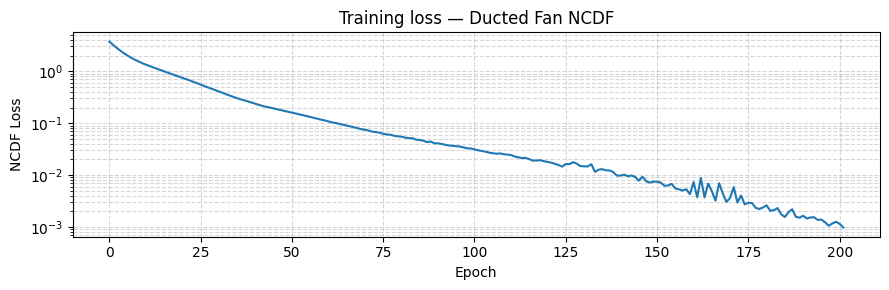

In [40]:
plt.figure(figsize=(9, 3))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("NCDF Loss")
plt.title("Training loss — Ducted Fan NCDF")
plt.yscale("log")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

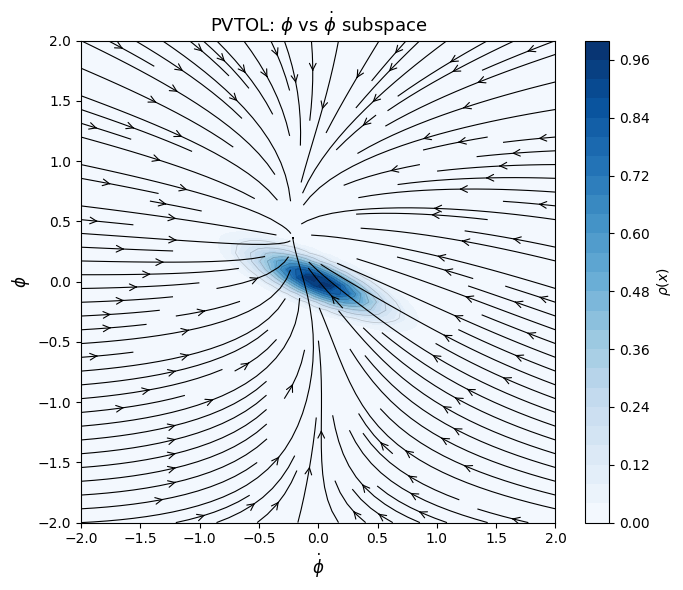

In [41]:
def plot_density_slice(a_nn, b_nn, c_nn, dim_i=0, dim_j=1,
                       fixed_vals=None, grid_size=60, state_range=2.0,
                       plot_flow=True, title_suffix=""):
    if fixed_vals is None:
        fixed_vals = torch.zeros(INPUT_DIM, device=device)

    xi_vals = torch.linspace(-state_range, state_range, grid_size)
    xj_vals = torch.linspace(-state_range, state_range, grid_size)
    Xi, Xj  = torch.meshgrid(xi_vals, xj_vals, indexing='ij')

    grid = fixed_vals.unsqueeze(0).unsqueeze(0).expand(grid_size, grid_size, -1).clone()
    grid[:, :, dim_i] = Xi
    grid[:, :, dim_j] = Xj
    grid_flat = grid.reshape(-1, INPUT_DIM)

    with torch.no_grad():
        a_vals = a_nn(grid_flat).squeeze()
        b_vals = b_nn(grid_flat)
        denom  = torch.exp(
            torch.sum(grid_flat**2, dim=1) +
            torch.sum(b_vals**2, dim=1)
        )
        rho    = (a_vals / denom).reshape(grid_size, grid_size)
        rho_max = rho.max().item()
        rho = rho / (rho_max + 1e-8)

    fig, ax = plt.subplots(figsize=(7, 6))
    state_labels = [r'$p_x$', r'$p_z$', r'$v_x$',
                    r'$v_z$', r'$\phi$', r'$\dot{\phi}$']

    cf = ax.contourf(Xi.numpy(), Xj.numpy(), rho.cpu().numpy(),
                     levels=30, cmap='Blues')
    ax.contour(Xi.numpy(), Xj.numpy(), rho.cpu().numpy(),
               levels=10, colors='k', linewidths=0.5, alpha=0.2)
    plt.colorbar(cf, ax=ax, label=r'$\rho(x)$')

    if plot_flow:
        # streamplot needs a regular grid and U, V arrays shaped (grid_size, grid_size)
        # NOTE: streamplot convention is U=d(x_j)/dt (horizontal) and V=d(x_i)/dt (vertical)
        # because the first axis of the grid is the x-axis of the plot
        U = torch.zeros(grid_size, grid_size)
        V = torch.zeros(grid_size, grid_size)

        with torch.no_grad():
            c_vals = c_nn(grid_flat)             # (N, 2)
            a_s    = a_nn(grid_flat).squeeze()   # (N,)
            u_vals = c_vals / a_s.unsqueeze(1)   # (N, 2)

        for k in range(grid_flat.shape[0]):
            xi_k = grid_flat[k]
            u_k  = u_vals[k]
            f_k  = f(xi_k)
            g_k  = g_matrix(xi_k)
            cl_k = f_k + g_k @ u_k              # closed-loop vector field, shape (6,)
            row = k // grid_size
            col = k % grid_size
            # streamplot: x-axis is dim_j, y-axis is dim_i
            U[row, col] = cl_k[dim_j].item()    # horizontal component
            V[row, col] = cl_k[dim_i].item()    # vertical component

        xi_np = xi_vals.numpy()   # grid for dim_i axis (y-axis of plot)
        xj_np = xj_vals.numpy()   # grid for dim_j axis (x-axis of plot)

        # streamplot(x, y, U, V): x varies along columns, y along rows
        # so pass xj_np as x, xi_np as y, and transpose U/V accordingly
        ax.streamplot(
            xj_np, xi_np,
            U.numpy(), V.numpy(),
            color='black',
            linewidth=0.8,
            arrowsize=1.2,
            density=1.2,        # increase for more stream lines, decrease for fewer
            arrowstyle='->',
        )

    ax.set_xlabel(state_labels[dim_j], fontsize=12)
    ax.set_ylabel(state_labels[dim_i], fontsize=12)
    ax.set_title(
        f"PVTOL: {state_labels[dim_i]} vs {state_labels[dim_j]} subspace",
        fontsize=13
    )
    ax.set_xlim(-state_range, state_range)
    ax.set_ylim(-state_range, state_range)
    plt.tight_layout()
    plt.show()




plot_density_slice(a_ret, b_ret, c_ret, dim_i=4, dim_j=5)